<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 6.1: Self-Attention and Multi-Head Latent Attention</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Self-Attention**

> **Reference:** Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). *Attention Is All You Need*. Advances in Neural Information Processing Systems (NeurIPS), 30. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)


#### **1. Attention as a Fuzzy Database Lookup**

**Goal:** Understand how attention mimics retrieving information, but in a "soft" or approximate way rather than an exact match.

Think of a regular database (like a hash table): you give it a query, and it returns exactly one matching key-value pair. Attention works differently — it compares the query against *every* key and returns a *weighted blend* of all values based on how well each key matches.

$$\text{Attention}(Q, V, K) = \sum_i \text{Similarity}(Q, K_i) \times V_i$$

Where:
- $Q$ = the query — what we're looking for
- $K_i$ = the $i$-th key — what we're comparing the query against
- $V_i$ = the $i$-th value — the information we want to retrieve
- $\text{Similarity}(Q, K_i)$ = a score measuring how well query $Q$ matches key $K_i$

Instead of one exact match, we get a **soft retrieval** — a mixture of all values, weighted by relevance.

<br>

#### **2. Scoring Functions for Attention**

The similarity score $S_i = f(Q, K_i)$ can be computed in several ways:

| Scoring Method | Formula | Notes |
|---|---|---|
| Dot product | $Q^T K_i$ | Simplest — just multiply and sum |
| Scaled dot product | $\frac{Q^T K_i}{\sqrt{d}}$ | Divides by $\sqrt{d}$ to prevent large values when dimensionality $d$ is high |
| General dot product | $Q^T W K_i$ | Introduces a learnable weight matrix $W$ for more flexibility |

#### **Why scale by $\sqrt{d}$?**
When the dimension $d$ is large, dot products tend to produce very large numbers. Passing those into softmax pushes the output toward extreme values (nearly 0 or 1), which kills gradients. Dividing by $\sqrt{d}$ keeps the scores in a reasonable range.

#### **In a machine translation setup:**
- **Query** = the hidden vector for the output word being generated
- **Key** = the hidden vector for each input word
- **Value** = also the hidden vector for each input word (often the same as the key)

The attention output is then a weighted combination of all the value vectors, where the weights reflect how relevant each input word is to the current output word.

<br>

#### **3. Self-Attention**

**Key idea:** Instead of attending from the decoder to the encoder (cross-attention), self-attention lets words attend to *other words within the same sequence*.

In standard (cross-)attention, the query comes from one sequence (e.g., the decoder) and the keys/values come from another (e.g., the encoder). In self-attention, all three — query, key, and value — come from the **same** sequence.

**Why this matters:** Each word can now directly gather context from every other word in the input. For example, in the sentence "The animal didn't cross the street because it was too tired," the word "it" can attend to "animal" to resolve what "it" refers to — without needing to pass information step-by-step through a chain of hidden states.

$$\text{SelfAttention}(X) = \text{Attention}(Q, K, V) \quad \text{where } Q, K, V \text{ all derive from } X$$

<br>

#### **4. RNNs vs. Transformers**

RNNs process sequences one step at a time, which creates several problems. Transformers were designed to solve all of them at once.

| Challenge | RNNs | Transformers |
|---|---|---|
| Long-range dependencies | Struggle — no explicit modelling of distant relationships | Handle well — every word can attend to every other word directly |
| Gradient flow | Prone to vanishing and exploding gradients over long sequences | Stable — shorter gradient paths through self-attention |
| Training efficiency | Require many training steps | Converge in fewer steps |
| Parallelization | Sequential by nature — each step depends on the previous one | Fully parallelizable — no recurrence needed |

#### **Why parallelization matters**
An RNN must process word 1 before word 2, word 2 before word 3, and so on. This makes training slow on modern GPUs which are designed for parallel computation. Transformers compute attention over all positions simultaneously, making them dramatically faster to train.

---

#### **Transformer ModeL: Scaled Dot-Product Self-Attention (Single Head)**

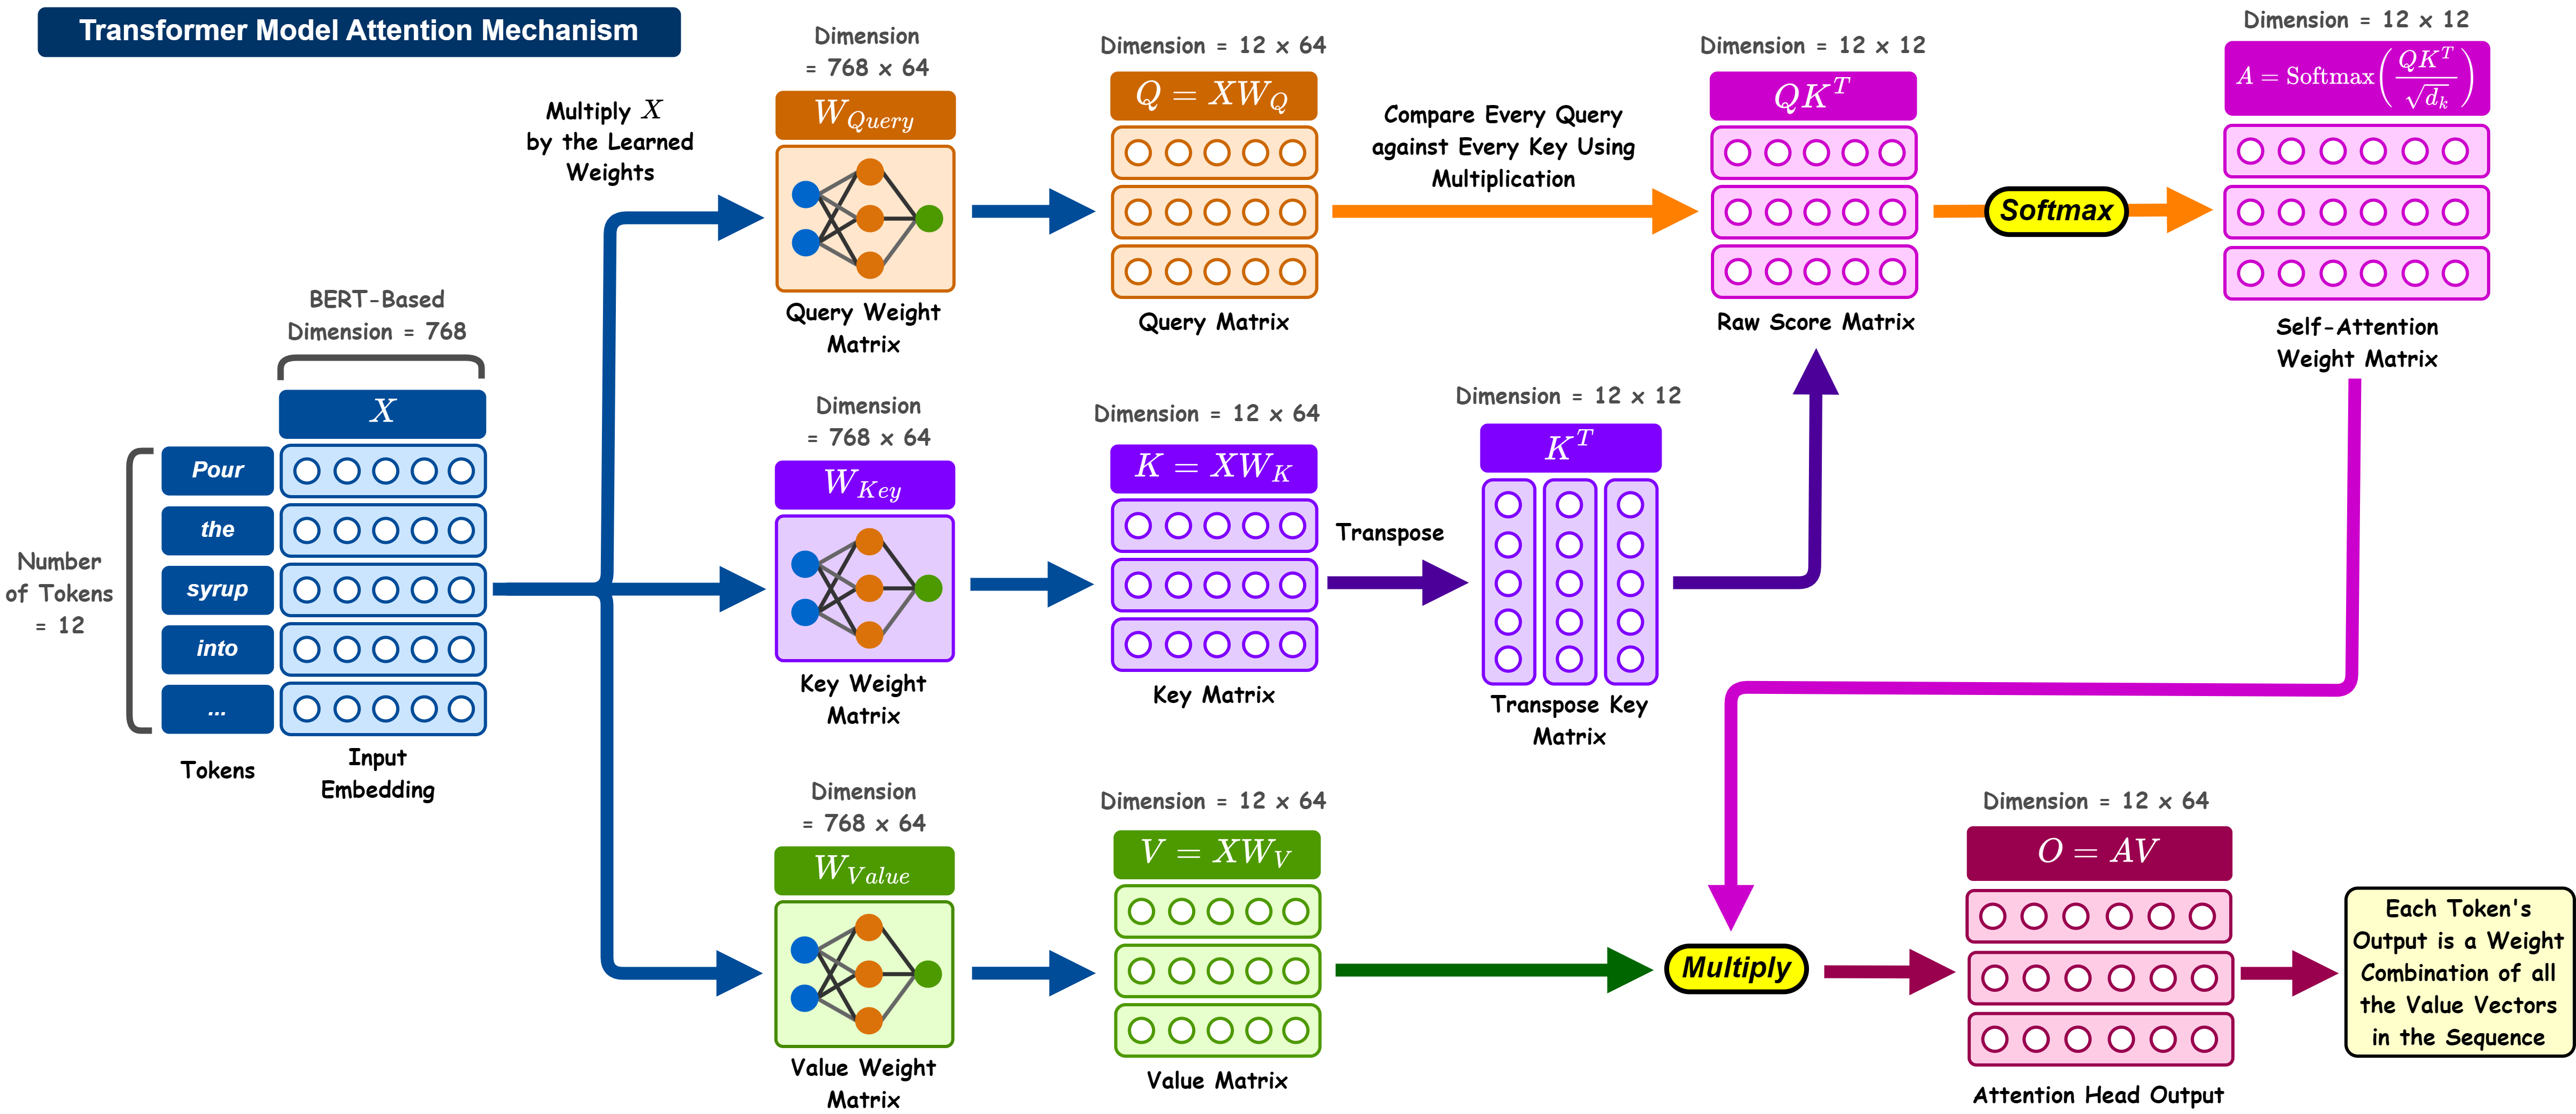

#### **Step 1: Input Matrix $X$**

Each token in the input sequence is represented as a $d_{\text{model}}$-dimensional embedding vector. Stack all $n$ tokens into a single matrix:

$$X \in \mathbb{R}^{n \times d_{\text{model}}}$$

Where:
- $X$ = the input matrix — each row is one token's embedding
- $n$ = number of tokens in the sequence
- $d_{\text{model}}$ = the full embedding dimension (e.g., 768 in BERT-base)

<br>

#### **Step 2: Project into Queries, Keys, and Values**

We multiply $X$ by three separate learned weight matrices to get three different "views" of the input:

$$Q = XW_Q \quad \quad K = XW_K \quad \quad V = XW_V$$

Where:
- $W_Q \in \mathbb{R}^{d_{\text{model}} \times d_k}$ = the query weight matrix — learned during training
- $W_K \in \mathbb{R}^{d_{\text{model}} \times d_k}$ = the key weight matrix — learned during training
- $W_V \in \mathbb{R}^{d_{\text{model}} \times d_v}$ = the value weight matrix — learned during training
- $Q \in \mathbb{R}^{n \times d_k}$ = the query matrix — what each token is "asking for"
- $K \in \mathbb{R}^{n \times d_k}$ = the key matrix — what each token "advertises" about itself
- $V \in \mathbb{R}^{n \times d_v}$ = the value matrix — the actual information each token carries
- $d_k$ = the dimension of queries and keys (e.g., 64)
- $d_v$ = the dimension of values (e.g., 64; often $d_k = d_v$)

#### **Why project?**
The raw embeddings serve a general purpose. Projecting into Q, K, V lets the model learn *separate* representations for "what am I looking for?", "what do I contain?", and "what should I pass along?"

<br>

#### **Step 3: Compute Raw Attention Scores**

Multiply queries by the transpose of keys to get a score for every pair of tokens:

$$QK^T \in \mathbb{R}^{n \times n}$$

Where:
- $QK^T$ = the raw score matrix — entry $(i, j)$ tells us how much token $i$'s query matches token $j$'s key
- $K^T \in \mathbb{R}^{d_k \times n}$ = the transpose of the key matrix

Each row $i$ contains the similarity scores of token $i$ against every other token in the sequence.

<br>

#### **Step 4: Scale and Softmax → Attention Weights**

$$A = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) \in \mathbb{R}^{n \times n}$$

Where:
- $A$ = the attention weight matrix (the "attention pattern")
- $\sqrt{d_k}$ = the scaling factor (e.g., $\sqrt{64} = 8$)
- Each row of $A$ sums to 1 — it's a probability distribution over which tokens to attend to
- $A_{ij}$ = how much attention token $i$ pays to token $j$

#### **Why scale by $\sqrt{d_k}$?**
Without scaling, large $d_k$ causes dot products to grow large in magnitude. When fed into softmax, this pushes outputs toward 0 or 1 (saturated softmax), which kills gradients. Dividing by $\sqrt{d_k}$ keeps scores in a range where softmax produces useful gradients.

<br>

#### **Step 5: Compute the Attention Output**

Multiply the attention weights by the value matrix:

$$O = AV \in \mathbb{R}^{n \times d_v}$$

Where:
- $O$ = the attention head output — each row is a context-aware representation of that token
- $A$ = the attention weights ($n \times n$)
- $V$ = the value matrix ($n \times d_v$)

Each token's output is now a weighted combination of *all* value vectors in the sequence, where the weights come from the attention pattern. Tokens that were deemed more relevant (higher $A_{ij}$) contribute more to the output.

<br>

#### **Full equation in one line**

$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

This is the core building block of the Transformer. In multi-head attention, you run $h$ of these in parallel (each with their own $W_Q$, $W_K$, $W_V$), concatenate the outputs, and project back to $d_{\text{model}}$ dimensions.

---

### **Multi-Head Latent Attention (MLA) With Weight Absorption**

> **Reference:** DeepSeek-AI. (2024). *DeepSeek-V2: A Strong, Economical, and Efficient Mixture-of-Experts Language Model*. [arXiv:2405.04434](https://arxiv.org/abs/2405.04434)

**Goal:** Reduce the massive memory cost of KV cache during inference without sacrificing the quality of standard Multi-Head Attention.

<br>

#### **The Problem: KV Cache Bottleneck**

During inference, standard MHA caches the $K$ and $V$ matrices for every token generated so far, at every layer. For long sequences this gets enormous:

$$\text{KV cache per token} = 2 \times n_h \times d_h \times l$$

Where:
- $n_h$ = number of attention heads
- $d_h$ = dimension per head
- $l$ = number of decoder layers
- The 2 is for storing both $K$ and $V$

<br>

#### **The MLA Idea: Compress, Cache, Decompress**

Instead of caching full-size $K$ and $V$, MLA compresses the input into a small **latent vector**, caches only that, and works entirely in the compressed space during attention.

<br>

#### **Step 1 — Compress input into KV latent vector**

$$L_{KV} = XW_{DKV}$$

Where:
- $X \in \mathbb{R}^{n \times d}$ = the input matrix ($n$ tokens, each with $d = 7168$ dimensions)
- $W_{DKV} \in \mathbb{R}^{d \times d_c}$ = the down-projection matrix ($7168 \times 576$)
- $L_{KV} \in \mathbb{R}^{n \times d_c}$ = the compressed KV latent matrix ($n \times 576$)
- $d_c = 576$ = the latent dimension, much smaller than the full KV size

**This is what gets cached.** Instead of storing full $K$ and $V$ (both $n \times n_h d_h$), we store only $L_{KV}$ ($n \times 576$).

<br>

#### **Step 2 — Project queries into the latent space**

Instead of computing full queries and full keys separately, MLA merges the query weight matrix and the key up-projection into a single combined matrix:

$$W_Q W_{UK}^T \in \mathbb{R}^{d \times d_c} = \mathbb{R}^{7168 \times 576}$$

Then project the input directly into the latent space:

$$\text{Queries in latent space} = X(W_Q W_{UK}^T) \in \mathbb{R}^{n \times 576}$$

Where:
- $W_Q$ = the original query weight matrix
- $W_{UK}$ = the key up-projection matrix
- $W_Q W_{UK}^T$ = the pre-merged matrix — this is the **weight absorption** trick

#### **Why merge?**
In standard attention you would compute $Q = XW_Q$ and $K = L_{KV} W_{UK}$ separately, then do $QK^T$. But since $QK^T = (XW_Q)(L_{KV} W_{UK})^T = X(W_Q W_{UK}^T) L_{KV}^T$, you can pre-compute $W_Q W_{UK}^T$ once and skip the separate key up-projection entirely. Fewer matrix multiplications = faster inference.

<br>

#### **Step 3 — Compute attention scores**

Transpose the KV latent and multiply with the projected queries:

$$X(W_Q W_{UK}^T) L_{KV}^T = QK^T \in \mathbb{R}^{n \times n}$$

Where:
- $X(W_Q W_{UK}^T) \in \mathbb{R}^{n \times 576}$ = queries projected into latent space
- $L_{KV}^T \in \mathbb{R}^{576 \times n}$ = transposed KV latent

The dot product happens in the compressed 576-dimensional space instead of the full $n_h \times d_h$ space — much cheaper.

<br>

#### **Step 4 — Scale, mask, and softmax**

$$A = \text{Softmax}\left(\frac{QK^T}{\sqrt{d}}\right) \in \mathbb{R}^{n \times n}$$

Where:
- $A$ = the attention weight matrix
- $\sqrt{d}$ = the scaling factor
- Masking is applied before softmax in the decoder (to prevent attending to future tokens)

<br>

#### **Step 5 — Compute weighted latents**

Multiply attention weights by the KV latent matrix:

$$AL_{KV} \in \mathbb{R}^{n \times 576}$$

Where:
- $A \in \mathbb{R}^{n \times n}$ = attention weights
- $L_{KV} \in \mathbb{R}^{n \times 576}$ = the cached KV latent matrix

The output is still in the compressed 576-dimensional latent space.

<br>

#### **Step 6 — Up-project and output**

Apply the merged value up-projection and output projection:

$$O = (AL_{KV})(W_{UV} W_O) \in \mathbb{R}^{n \times d}$$

Where:
- $W_{UV} W_O \in \mathbb{R}^{d_c \times d} = \mathbb{R}^{576 \times 7168}$ = the pre-merged value up-projection + output projection
- $O \in \mathbb{R}^{n \times 7168}$ = the final attention output, back in the full model dimension

Again, $W_{UV}$ and $W_O$ are merged into a single matrix to save computation.

<br>

#### **Full pipeline summary**

$$X \xrightarrow{W_{DKV}} L_{KV} \text{ (cache this)}$$

$$X \xrightarrow{W_Q W_{UK}^T} \text{Queries in latent space}$$

$$X(W_Q W_{UK}^T) \cdot L_{KV}^T \xrightarrow{\text{scale + mask + softmax}} A$$

$$A \cdot L_{KV} \xrightarrow{W_{UV} W_O} O$$

<br>

#### **KV Cache Comparison**

| Method | What gets cached per token | Size |
|---|---|---|
| MHA | Full $K$ and $V$ | $2 \times n_h \times d_h$ |
| GQA | Grouped $K$ and $V$ | $2 \times n_g \times d_h$ |
| MQA | Single shared $K$ and $V$ | $2 \times d_h$ |
| **MLA** | Just $L_{KV}$ | $d_c$ (e.g., 576) |

MLA caches a single compressed latent vector per token instead of full keys and values — achieving cache size comparable to MQA while maintaining performance equal to or better than full MHA.

<br>

#### **Why this works intuitively**

Think of it like image compression (e.g., JPEG). The full $K$ and $V$ matrices contain redundant information. MLA learns a low-rank compression that preserves the important structure while dramatically reducing storage. When you need the full information, the up-projection matrices ($W_{UK}$, $W_{UV}$) decompress it — but thanks to weight absorption, even this decompression is folded into adjacent matrix multiplications so it costs nothing extra.